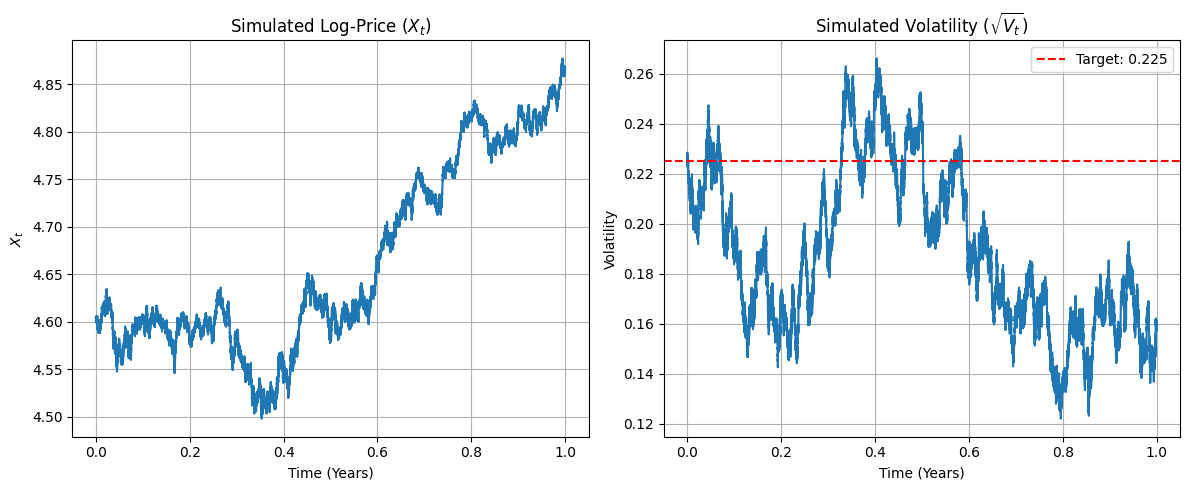

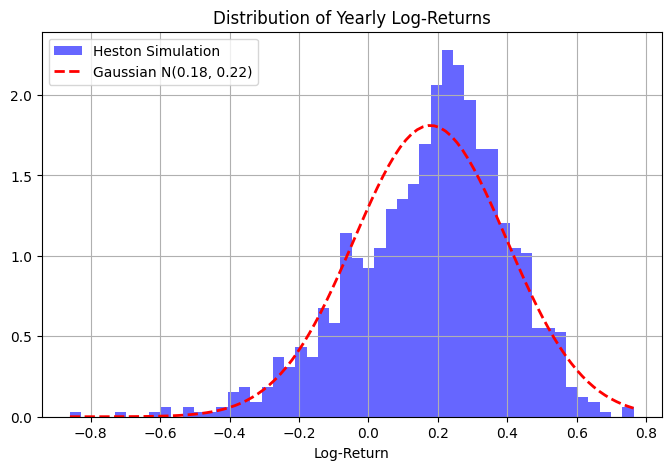

Simulation Mean: 0.1786 (Target: 0.1788)
Simulation Volatility: 0.2203 (Target: 0.225)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = 0.1788
sigma_target = 0.225
theta = sigma_target**2
v0 = theta

kappa = 3.0
xi = 0.3
rho = -0.7

T = 1.0
trading_days = 252
minutes_per_day = 390
N = trading_days * minutes_per_day
dt = T / N

def simulate_heston(n_paths):
    X = np.zeros((n_paths, N + 1))
    V = np.zeros((n_paths, N + 1))

    X[:, 0] = np.log(100)
    V[:, 0] = v0
    Z1 = np.random.normal(0, 1, (n_paths, N))
    Z2_uncorr = np.random.normal(0, 1, (n_paths, N))
    Z2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2_uncorr

    for t in range(N):
        v_curr = V[:, t]
        v_curr_pos = np.maximum(v_curr, 0)
        sqrt_v = np.sqrt(v_curr_pos)
        dv = kappa * (theta - v_curr_pos) * dt + xi * sqrt_v * np.sqrt(dt) * Z2[:, t]
        V[:, t+1] = v_curr + dv


        dx_task = mu * dt + sqrt_v * np.sqrt(dt) * Z1[:, t]
        X[:, t+1] = X[:, t] + dx_task

    return X, V

X_single, V_single = simulate_heston(1)
time_grid = np.linspace(0, T, N + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(time_grid, X_single[0])
plt.title(r"Simulated Log-Price ($X_t$)")
plt.xlabel("Time (Years)")
plt.ylabel("$X_t$")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(time_grid, np.sqrt(np.maximum(V_single[0], 0)))
plt.title(r"Simulated Volatility ($\sqrt{V_t}$)")
plt.xlabel("Time (Years)")
plt.ylabel("Volatility")
plt.axhline(sigma_target, color='r', linestyle='--', label=f"Target: {sigma_target}")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

n_sims = 1000
X_many, _ = simulate_heston(n_sims)

yearly_log_returns = X_many[:, -1] - X_many[:, 0]

mean_sim = np.mean(yearly_log_returns)
std_sim = np.std(yearly_log_returns)
x_axis = np.linspace(min(yearly_log_returns), max(yearly_log_returns), 100)
pdf_normal = norm.pdf(x_axis, mean_sim, std_sim)

plt.figure(figsize=(8, 5))
plt.hist(yearly_log_returns, bins=50, density=True, alpha=0.6, color='blue', label='Heston Simulation')
plt.plot(x_axis, pdf_normal, 'r--', linewidth=2, label=f'Gaussian N({mean_sim:.2f}, {std_sim:.2f})')
plt.title("Distribution of Yearly Log-Returns")
plt.xlabel("Log-Return")
plt.legend()
plt.grid(True)
plt.show()

print(f"Simulation Mean: {mean_sim:.4f} (Target: {mu})")
print(f"Simulation Volatility: {std_sim:.4f} (Target: {sigma_target})")